# Clase: Superficies en Datos Espaciales
### Basado en: *Geographic Data Science with Python* — Capítulo 3: Datos Espaciales
---
**Autores originales:** Sergio J. Rey, Dani Arribas-Bel, Levi J. Wolf  
**Adaptación al español:** Clase práctica en Jupyter Notebook

---

Objetivos de la clase

Al finalizar esta clase, el estudiante será capaz de:

1. Comprender qué es una **superficie** en el contexto de datos espaciales
2. Leer y manipular datos raster usando `rioxarray` y `xarray`
3. Visualizar superficies y manejar valores faltantes
4. Convertir superficies en tablas (y viceversa)
5. Agregar píxeles en geometrías (estadísticas zonales)
6. Convertir tablas de puntos en superficies usando `datashader`

---

## Contexto teórico

En ciencia de datos geográficos existen **tres estructuras de datos principales**:

| Estructura | Modelo de datos | Librería en Python |
|---|---|---|
| Tablas geográficas | Modelo de objetos | `geopandas` (GeoDataFrame) |
| **Superficies** | **Modelo de campos** | **`xarray` / `rioxarray` (DataArray)** |
| Grafos espaciales | Modelo de redes | `networkx` / `osmnx` |

En esta clase nos enfocamos en las **Superficies**.

---
## 1. ¿Qué es una Superficie?

Una **superficie** (o *raster*) representa datos bajo el **modelo de campo continuo**.

- En teoría, un campo es una superficie continua con infinitas ubicaciones medibles.
- En la práctica, los campos se miden en una **muestra finita y uniforme** de ubicaciones.
- Las superficies se representan como **grillas** donde cada celda contiene un valor.

**Diferencia clave con las tablas geográficas:**
- En tablas geográficas → la geografía está confinada a *una sola columna* (`geometry`)
- En superficies → *todas las dimensiones* están directamente vinculadas a una ubicación geográfica

### Ejemplos de superficies:
- Temperatura global (campo continuo interpolado)
- Modelos de elevación digital (DEM)
- Densidad de población por celda
- Imágenes satelitales (múltiples bandas)

---
## 2. Configuración del entorno

In [1]:
# Importaciones necesarias
import pandas
import geopandas
import rioxarray
import xarray
import datashader
import contextily as cx
from shapely import geometry
import matplotlib.pyplot as plt



Matplotlib is building the font cache; this may take a moment.


---
## 3. Lectura de una superficie raster

Trabajaremos con un extracto de un **dataset global de población** (GHSL) para la ciudad de **São Paulo, Brasil**.

- El archivo está en formato **GeoTIFF** (`.tif`): una variación del formato TIF que incluye información geográfica.
- Usamos el método `open_rasterio()` de `rioxarray` para leerlo.

In [2]:
# Leer el archivo GeoTIFF con rioxarray
pop = rioxarray.open_rasterio("datos/external/ghsl/ghsl_sao_paulo.tif")

# Verificar el tipo de dato resultante
print("Tipo de dato:", type(pop))

Tipo de dato: <class 'xarray.core.dataarray.DataArray'>


In [3]:
pop

<xarray.DataArray (band: 1, y: 416, x: 468)> Size: 779kB
[194688 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 3kB -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
  * x            (x) float64 4kB -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -200.0
    scale_factor:   1.0
    add_offset:     0.0

## 📋 Atributos del DataArray (`pop.attrs`)

Cuando cargamos un archivo raster con `rioxarray`, el objeto `DataArray` incluye **metadatos** que describen cómo interpretar los datos almacenados.

| Atributo | Valor | Significado |
|---|---|---|
| `AREA_OR_POINT` | `Area` | Cada píxel representa un **área** de 250m × 250m, no un punto exacto |
| `_FillValue` | `-200.0` | Valor usado para indicar **"sin datos"**. Hay que filtrarlo con `where(pop != -200)` |
| `scale_factor` | `1.0` | Los valores **no están comprimidos**. El valor real = valor guardado × 1.0 |
| `add_offset` | `0.0` | **No hay desplazamiento**. El valor real = valor guardado + 0.0 |

> En este dataset los valores se leen tal cual, sin transformaciones. El único cuidado necesario es filtrar las celdas con `-200`, que representan zonas sin información.

In [4]:
# Ver la resolución espacial del raster en metros
pop.rio.resolution()

(250.0, -250.0)

### 3.1 El objeto `DataArray` de `xarray`

`xarray` es un paquete para trabajar con **arreglos multidimensionales etiquetados**.

- Permite arreglos de más de dos dimensiones (no solo filas y columnas)
- Cada dimensión es rastreada por un **índice** (llamado *coordenada*)
- Las coordenadas se acceden con el atributo `.coords`

In [5]:
# Explorar las coordenadas del DataArray
print("Coordenadas del DataArray:")
print(pop.coords)

Coordenadas del DataArray:
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 3kB -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
  * x            (x) float64 4kB -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06
    spatial_ref  int64 8B 0


In [6]:
# Ver los atributos del DataArray
print("Atributos (metadatos):")
print(pop.attrs)

Atributos (metadatos):
{'AREA_OR_POINT': 'Area', '_FillValue': np.float32(-200.0), 'scale_factor': 1.0, 'add_offset': 0.0}


In [7]:
# Ver las dimensiones del array
print("Forma (shape) del DataArray:", pop.shape)
print()
print("Interpretación:")
print(f"  - {pop.shape[0]} banda(s)")
print(f"  - {pop.shape[1]} filas (dimensión Y)")
print(f"  - {pop.shape[2]} columnas (dimensión X)")

Forma (shape) del DataArray: (1, 416, 468)

Interpretación:
  - 1 banda(s)
  - 416 filas (dimensión Y)
  - 468 columnas (dimensión X)


### 3.2 Dimensiones de una superficie

Nuestra superficie tiene **tres dimensiones**: `band`, `x`, `y`:

| Dimensión | Descripción |
|---|---|
| `x` | Longitud de cada celda |
| `y` | Latitud de cada celda |
| `band` | Dimensión adicional (puede ser tiempo, canal RGB, NIR, etc.) |

💡 **¿Cuándo es útil la dimensión `band`?**
- Una imagen a color tiene 3 bandas: Rojo, Verde, Azul (RGB)
- Un sensor avanzado puede incluir Infrarrojo cercano (NIR)
- Una serie temporal tiene una banda por cada momento medido

Podemos seleccionar solo las dimensiones geográficas con el operador `sel()`:

In [8]:
# Seleccionar solo la banda 1 (reducir a 2 dimensiones geográficas)
pop_2d = pop.sel(band=1)
print("Dimensiones después de seleccionar banda 1:", pop_2d.shape)
pop_2d

Dimensiones después de seleccionar banda 1: (416, 468)


<xarray.DataArray (y: 416, x: 468)> Size: 779kB
[194688 values with dtype=float32]
Coordinates:
  * y            (y) float64 3kB -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
  * x            (x) float64 4kB -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -200.0
    scale_factor:   1.0
    add_offset:     0.0

In [9]:
print(pop.spatial_ref)

<xarray.DataArray 'spatial_ref' ()> Size: 8B
array(0)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    crs_wkt:       PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",...
    spatial_ref:   PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",...
    GeoTransform:  -4482000.0 250.0 0.0 -2822000.0 0.0 -250.0


---
## 4. Visualización de superficies

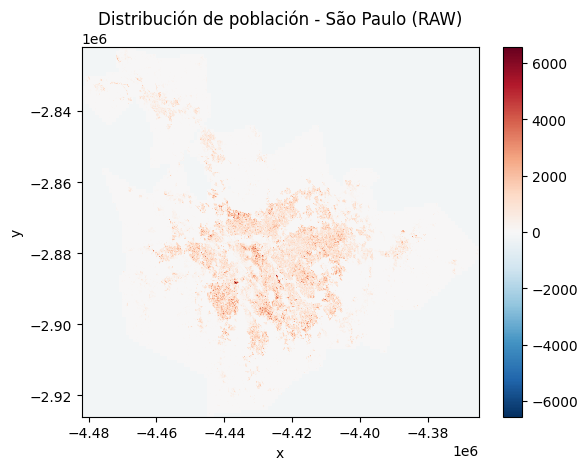

In [10]:
# Visualización básica de la superficie
pop.sel(band=1).plot()
plt.title("Distribución de población - São Paulo (RAW)")
plt.show()

### 4.1 Manejo de valores faltantes

**¡Atención!** El mapa anterior muestra conteos negativos... ¿cómo es eso posible?

En superficies, los **datos faltantes** se almacenan tradicionalmente con un **valor sin sentido como -200** (no como `NaN`). 

Si revisamos los atributos: el campo `_FillValue` indica que el valor `-200` representa datos faltantes.

Usamos el método `where()` para filtrar y mostrar solo valores válidos:

Valor de NoData (datos faltantes): -200.0


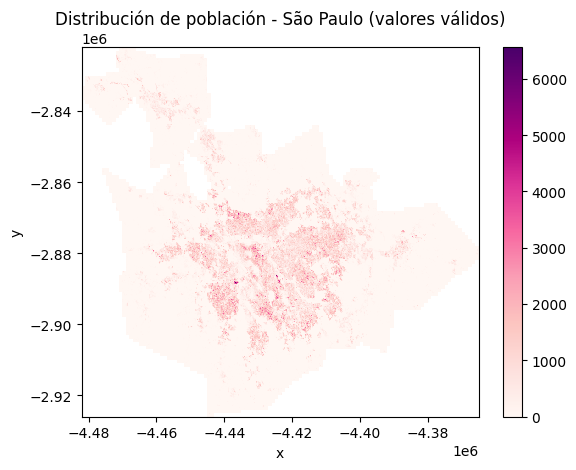

In [11]:
# Ver el valor NoData
print("Valor de NoData (datos faltantes):", pop.attrs.get('_FillValue', 'No especificado'))

# Filtrar valores faltantes con where()
pop.where(pop != -200).sel(band=1).plot(cmap="RdPu")
plt.title("Distribución de población - São Paulo (valores válidos)")
plt.show()

In [12]:
# Ejercicio: ¿Cuántos píxeles tienen valores válidos?
pop_validos = pop.where(pop != -200)
n_total = pop.sel(band=1).size
n_validos = int((pop.sel(band=1) != -200).sum())
n_faltantes = n_total - n_validos

print(f"Total de píxeles: {n_total:,}")
print(f"Píxeles con datos válidos: {n_validos:,} ({100*n_validos/n_total:.1f}%)")
print(f"Píxeles faltantes (NoData): {n_faltantes:,} ({100*n_faltantes/n_total:.1f}%)")

Total de píxeles: 194,688
Píxeles con datos válidos: 97,232 (49.9%)
Píxeles faltantes (NoData): 97,456 (50.1%)


---
## 5. Superficies como tablas (Híbridos)

### 5.1 Concepto: ¿Por qué convertir superficies a tablas?

**Desventajas de convertir a tabla:**
- Se pierde (o hay que reconstruir) la referencia espacial implícita
- Es menos eficiente que algoritmos especializados para raster
- Puede ser estadísticamente incorrecto tratar píxeles como observaciones independientes

**Ventajas de convertir a tabla:**
- Acceso a toda la tecnología tabular: `pandas`, `scikit-learn`, Pysal...
- Compatible con sistemas "big data" (computación distribuida con `dask`)
- Más simple cuando NO necesitamos la referencia espacial
- Facilita consultas y filtros con `query()`

### 5.2 Un píxel por fila (`to_series()`)

In [13]:
# Leer la superficie nuevamente
surface = rioxarray.open_rasterio("datos/external/ghsl/ghsl_sao_paulo.tif")

surface

<xarray.DataArray (band: 1, y: 416, x: 468)> Size: 779kB
[194688 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 3kB -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
  * x            (x) float64 4kB -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -200.0
    scale_factor:   1.0
    add_offset:     0.0

In [14]:
# Convertir a Serie de pandas (cada píxel = una fila)
t_surface = surface.to_series()
t_surface

band  y           x         
1     -2822125.0  -4481875.0   -200.0
                  -4481625.0   -200.0
                  -4481375.0   -200.0
                  -4481125.0   -200.0
                  -4480875.0   -200.0
                                ...  
      -2925875.0  -4366125.0   -200.0
                  -4365875.0   -200.0
                  -4365625.0   -200.0
                  -4365375.0   -200.0
                  -4365125.0   -200.0
Length: 194688, dtype: float32

In [15]:

t_surface.head()

band  y           x         
1     -2822125.0  -4481875.0   -200.0
                  -4481625.0   -200.0
                  -4481375.0   -200.0
                  -4481125.0   -200.0
                  -4480875.0   -200.0
dtype: float32

In [16]:
# Convertir a DataFrame con reset_index()
t_surface = t_surface.reset_index().rename(columns={0: "Valor"})
t_surface.head()

,band,y,x,Valor
0,1,-2822125.0,-4481875.0,-200.0
1,1,-2822125.0,-4481625.0,-200.0
2,1,-2822125.0,-4481375.0,-200.0
3,1,-2822125.0,-4481125.0,-200.0
4,1,-2822125.0,-4480875.0,-200.0


In [ ]:

# Encontrar celdas con más de 1,000 personas
celdas_densas = t_surface[t_surface["Valor"] > 1000]
#celdas_densas = t_surface.query("Valor > 1000")

print(f"Celdas con más de 1,000 personas: {len(celdas_densas):,}")


Celdas con más de 1,000 personas: 7,734


In [18]:
# Estadísticas descriptivas de los valores de población válidos
pop_valida = t_surface[t_surface["Valor"] > 1000]
print("Estadísticas de población")
print(pop_valida["Valor"].describe())

Estadísticas de población
count    7734.000000
mean     1463.897583
std       449.900452
min      1000.052673
25%      1143.723694
50%      1334.383179
75%      1649.589203
max      6563.036621
Name: Valor, dtype: float64


### 5.3 De píxeles a polígonos (GeoDataFrame)

Podemos convertir los píxeles seleccionados en una **tabla geográfica completa** con geometrías reales:

In [19]:
# Función para convertir una fila (píxel) en su geometría cuadrada
def fila_a_celda(fila, resolucion_xy):
    """Convierte un píxel del raster en un polígono cuadrado."""
    res_x, res_y = resolucion_xy  # Resolución en cada dimensión
    # Las coordenadas XY están centradas en el píxel
    minX = fila["x"] - (res_x / 2)
    maxX = fila["x"] + (res_x / 2)
    minY = fila["y"] + (res_y / 2)
    maxY = fila["y"] - (res_y / 2)
    poligono = geometry.box(minX, minY, maxX, maxY)  # Polígono cuadrado
    return poligono

# Probar con la primera fila
ejemplo = fila_a_celda(t_surface.loc[0, :], surface.rio.resolution())
print("Geometría del primer píxel:")
print(ejemplo)

Geometría del primer píxel:
POLYGON ((-4481750 -2822250, -4481750 -2822000, -4482000 -2822000, -4482000 -2822250, -4481750 -2822250))


In [20]:
# Crear GeoDataFrame para celdas con más de 1,000 habitantes
# Paso 1: Construir un polígono para cada celda
poligonos = pop_valida.apply(fila_a_celda, resolucion_xy=surface.rio.resolution(), axis=1)

poligonos

3785      POLYGON ((-4471500 -2824250, -4471500 -2824000...
4252      POLYGON ((-4471750 -2824500, -4471750 -2824250...
5658      POLYGON ((-4471250 -2825250, -4471250 -2825000...
6126      POLYGON ((-4471250 -2825500, -4471250 -2825250...
6595      POLYGON ((-4471000 -2825750, -4471000 -2825500...
                                ...                        
178515    POLYGON ((-4430000 -2917500, -4430000 -2917250...
178516    POLYGON ((-4429750 -2917500, -4429750 -2917250...
178983    POLYGON ((-4430000 -2917750, -4430000 -2917500...
179904    POLYGON ((-4433750 -2918250, -4433750 -2918000...
181296    POLYGON ((-4436750 -2919000, -4436750 -2918750...
Length: 7734, dtype: object

In [21]:
# Paso 2: Agregar los polígonos como columna geometry
pop_valida["geometry"] = poligonos

/var/folders/nc/d5q5pv0177x4vc6_ryc6qwn00000gn/T/ipykernel_5556/3711599831.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_valida["geometry"] = poligonos


In [22]:
# Paso 3: Convertir a GeoDataFrame
poligonos_densos = geopandas.GeoDataFrame(pop_valida, crs=surface.rio.crs)
poligonos_densos

,band,y,x,Valor,geometry
3785,1,-2824125.0,-4471625.0,1779.026123,"POLYGON ((-4471500.000 -2824250.000, -4471500...."
4252,1,-2824375.0,-4471875.0,1051.851807,"POLYGON ((-4471750.000 -2824500.000, -4471750...."
5658,1,-2825125.0,-4471375.0,2005.445679,"POLYGON ((-4471250.000 -2825250.000, -4471250...."
6126,1,-2825375.0,-4471375.0,1506.296143,"POLYGON ((-4471250.000 -2825500.000, -4471250...."
6595,1,-2825625.0,-4471125.0,1263.809937,"POLYGON ((-4471000.000 -2825750.000, -4471000...."
...,...,...,...,...,...
178515,1,-2917375.0,-4430125.0,1105.572266,"POLYGON ((-4430000.000 -2917500.000, -4430000...."
178516,1,-2917375.0,-4429875.0,1055.646729,"POLYGON ((-4429750.000 -2917500.000, -4429750...."
178983,1,-2917625.0,-4430125.0,1105.572266,"POLYGON ((-4430000.000 -2917750.000, -4430000...."
179904,1,-2918125.0,-4433875.0,1012.583740,"POLYGON ((-4433750.000 -2918250.000, -4433750...."


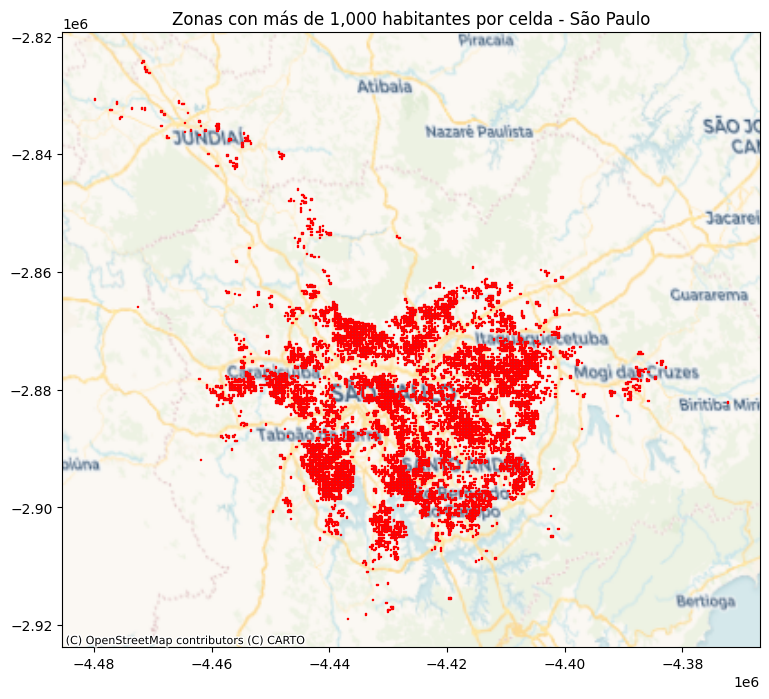

In [23]:
# Visualizar las zonas de alta densidad poblacional
ax = poligonos_densos.plot(edgecolor="red", figsize=(9, 9))

# Agregar mapa base
cx.add_basemap(
    ax, crs=surface.rio.crs, source=cx.providers.CartoDB.Voyager
)
ax.set_title("Zonas con más de 1,000 habitantes por celda - São Paulo", fontsize=12)
plt.show()

### 5.4 Regresar de tabla a superficie (`from_series()`)

El viaje inverso también es posible: de tabla → superficie:

In [24]:
# Reconstruir el DataArray desde la tabla
nuevo_da = xarray.DataArray.from_series(
    t_surface.set_index(["band", "y", "x"])["Valor"]
)

print("✅ DataArray reconstruido desde tabla:")
nuevo_da

✅ DataArray reconstruido desde tabla:


<xarray.DataArray 'Valor' (band: 1, y: 416, x: 468)> Size: 779kB
array([[[-200., -200., -200., ..., -200., -200., -200.],
        [-200., -200., -200., ..., -200., -200., -200.],
        [-200., -200., -200., ..., -200., -200., -200.],
        ...,
        [-200., -200., -200., ..., -200., -200., -200.],
        [-200., -200., -200., ..., -200., -200., -200.],
        [-200., -200., -200., ..., -200., -200., -200.]]],
      shape=(1, 416, 468), dtype=float32)
Coordinates:
  * band     (band) int64 8B 1
  * y        (y) float64 3kB -2.926e+06 -2.926e+06 ... -2.822e+06 -2.822e+06
  * x        (x) float64 4kB -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06

---
## 6. Píxeles a polígonos: Estadísticas Zonales

Un segundo caso de conversión superficie → tabla consiste en **agregar píxeles dentro de geometrías predefinidas**.

### Caso práctico: Altitud promedio por barrio en San Diego

Datos utilizados:
- 🏔️ **Modelo de Elevación Digital (DEM)** de la NASA para San Diego
- 🗺️ **Tracts censales** de San Diego (polígonos de barrios)

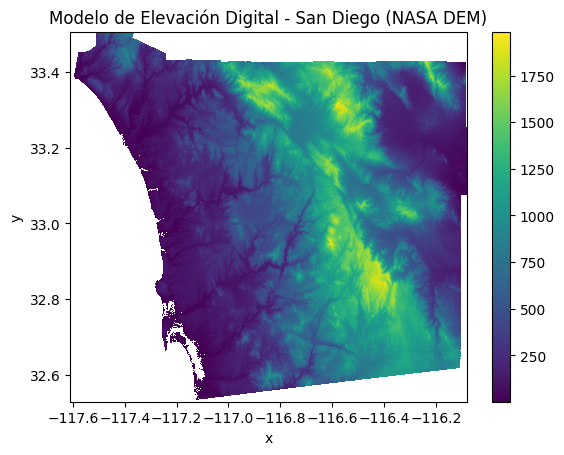

In [26]:
# Leer el Modelo de Elevación Digital (DEM)
dem = rioxarray.open_rasterio("datos/external/nasadem/nasadem_sd.tif").sel(band=1)

# Visualizar la elevación (solo valores positivos = sobre el nivel del mar)
dem.where(dem > 0).plot.imshow()
plt.title("Modelo de Elevación Digital - San Diego (NASA DEM)", fontsize=12)
plt.show()

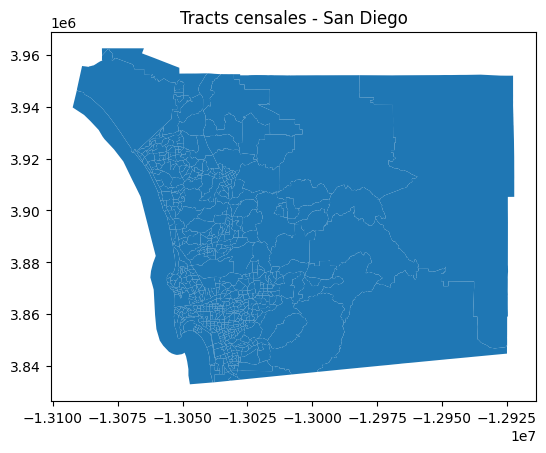


Número de tracts: 628


In [27]:
# Leer los tracts censales (barrios)
sd_tracts = geopandas.read_file("datos/external/sandiego/sandiego_tracts.gpkg")

sd_tracts.plot()
plt.title("Tracts censales - San Diego", fontsize=12)
plt.show()

print(f"\nNúmero de tracts: {len(sd_tracts)}")

In [28]:
sd_tracts

,GEOID,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,median_hh_income,income_gini,...,state,county,tract,area_sqm,pct_rented,pct_hh_female,pct_bachelor,pct_white,sub_30,geometry
0,06073018300,37.1,2590.0,2375.0,1299.0,2590.0,137.0,0.0,62500.0,0.5355,...,06,073,018300,2.876449,0.373913,0.052896,0.000000,0.916988,False,"POLYGON ((-13069450.120 3922380.770, -13069175..."
1,06073018601,41.2,5147.0,4069.0,1970.0,5147.0,562.0,24.0,88165.0,0.4265,...,06,073,018601,4.548797,0.205144,0.109190,0.004663,0.790558,False,"POLYGON ((-13067719.770 3922939.420, -13067631..."
2,06073017601,54.4,5595.0,4925.0,1702.0,5595.0,442.0,34.0,110804.0,0.4985,...,06,073,017601,8.726275,0.279029,0.078999,0.006077,0.880250,False,"POLYGON ((-13058166.110 3907247.690, -13058140..."
3,06073019301,42.3,7026.0,5625.0,3390.0,7026.0,638.0,46.0,100539.0,0.4003,...,06,073,019301,3.519743,0.196512,0.090806,0.006547,0.800598,False,"POLYGON ((-13056896.290 3925255.610, -13056868..."
4,06073018700,21.8,40402.0,30455.0,24143.0,40402.0,2456.0,23.0,41709.0,0.3196,...,06,073,018700,559.150793,0.949887,0.060789,0.000569,0.753799,False,"POLYGON ((-13090788.510 3946435.430, -13090736..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623,06073020709,41.6,7848.0,5633.0,3512.0,7848.0,808.0,88.0,95132.0,0.3628,...,06,073,020709,107.593049,0.127660,0.102956,0.011213,0.717762,False,"POLYGON ((-13029476.960 3912060.390, -13029476..."
624,06073020805,36.2,3624.0,2759.0,1681.0,3624.0,392.0,0.0,63820.0,0.3498,...,06,073,020805,7.239568,0.341730,0.108168,0.000000,0.761313,False,"POLYGON ((-13014919.160 3898901.850, -13014868..."
625,06073020810,44.5,5261.0,4977.0,2101.0,5261.0,617.0,26.0,106319.0,0.3336,...,06,073,020810,39.028783,0.111605,0.117278,0.004942,0.946018,False,"POLYGON ((-13009524.170 3896636.950, -13009524..."
626,06073021206,46.0,3065.0,2628.0,1373.0,3065.0,303.0,15.0,104375.0,0.4050,...,06,073,021206,42.849263,0.098882,0.098858,0.004894,0.857423,False,"POLYGON ((-13002757.840 3875229.320, -13002735..."


### 6.1 Recortar el raster para un polígono individual

In [29]:
# Encontrar el tract más grande (borde este de San Diego)
id_tract_mayor = sd_tracts.query(
    f"area_sqm == {sd_tracts['area_sqm'].max()}"
).index[0]

print(f"ID del tract más grande: {id_tract_mayor}")

# Extraer el polígono
tract_mayor = sd_tracts.loc[id_tract_mayor, "geometry"]

ID del tract más grande: 627


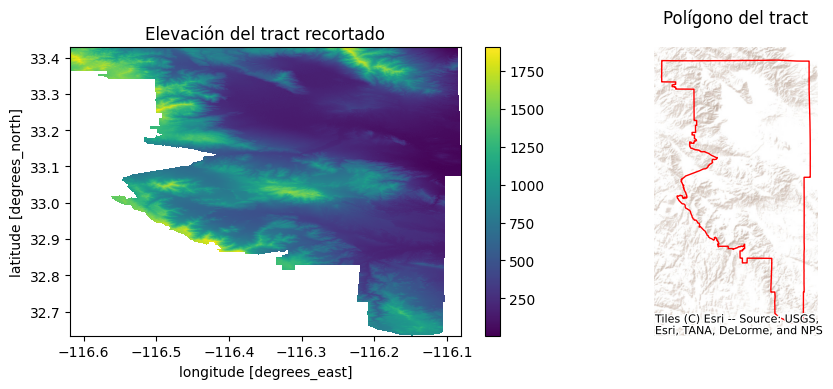

In [30]:
# Recortar (clip) la elevación dentro del polígono
dem_recortado = dem.rio.clip(
    [tract_mayor.__geo_interface__], crs=sd_tracts.crs
)

# Visualizar comparación
f, axs = plt.subplots(1, 2, figsize=(10, 4))

# Izquierda: elevación del tract recortado
dem_recortado.where(dem_recortado > 0).plot(ax=axs[0], add_colorbar=True)
axs[0].set_title("Elevación del tract recortado")

# Derecha: polígono del tract
sd_tracts.loc[[id_tract_mayor]].plot(
    ax=axs[1], edgecolor="red", facecolor="none"
)
axs[1].set_axis_off()
cx.add_basemap(axs[1], crs=sd_tracts.crs, source=cx.providers.Esri.WorldTerrain)
axs[1].set_title("Polígono del tract")

plt.tight_layout()
plt.show()

In [31]:
# Calcular elevación promedio del tract más grande
elevacion_promedio = float(dem_recortado.where(dem_recortado > 0).mean())
print(f"⛰️  Elevación promedio del tract más grande: {elevacion_promedio:.1f} metros")

⛰️  Elevación promedio del tract más grande: 585.1 metros


### 6.2 Aplicar a todos los barrios (estadísticas zonales con `rasterstats`)

In [33]:
from rasterstats import zonal_stats

# Calcular estadísticas de elevación para TODOS los tracts
elevaciones = zonal_stats(
    sd_tracts.to_crs(dem.rio.crs),       # Geometrías de los tracts (en CRS del DEM)
    "datos/external/nasadem/nasadem_sd.tif",    # Ruta al archivo raster
)

# Convertir a DataFrame
elevaciones_df = pandas.DataFrame(elevaciones)

print("✅ Estadísticas zonales calculadas:")
elevaciones_df.head(10)

✅ Estadísticas zonales calculadas:


,min,max,mean,count
0,-12.0,18.0,3.538397,3594
1,-2.0,94.0,35.616395,5709
2,-5.0,121.0,48.742630,10922
3,31.0,149.0,91.358777,4415
4,-32.0,965.0,184.284941,701973
5,-6.0,56.0,14.071978,1431
6,41.0,99.0,75.338667,2625
7,26.0,274.0,125.542039,30959
8,22.0,100.0,57.087912,2366
9,-1.0,126.0,46.253900,9102


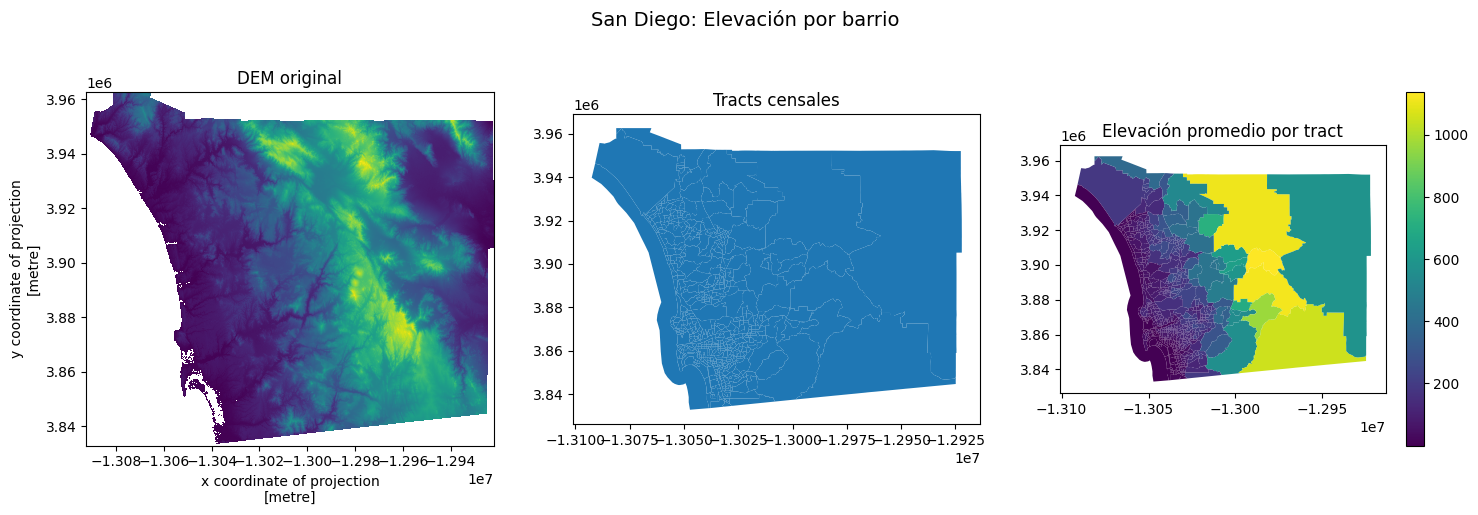

In [34]:
# Visualizar los resultados: elevación promedio por barrio
f, axs = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Superficie de elevación original
dem.where(dem > 0).rio.reproject(sd_tracts.crs).plot.imshow(
    ax=axs[0], add_colorbar=False
)
axs[0].set_title("DEM original")

# Panel 2: Tracts censales
sd_tracts.plot(ax=axs[1])
axs[1].set_title("Tracts censales")

# Panel 3: Elevación promedio por tract (coropleta)
sd_tracts.assign(elevacion=elevaciones_df["mean"]).plot(
    "elevacion", ax=axs[2], legend=True
)
axs[2].set_title("Elevación promedio por tract")

plt.suptitle("San Diego: Elevación por barrio", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Tablas como superficies: Agregación de puntos

El caso inverso: convertir una **tabla de puntos** en una **superficie**.

### ¿Cuándo tiene sentido esto?
- Cuando tenemos **demasiados puntos** para visualizar individualmente
- Cuando nos interesa la **distribución general** (densidad)
- Cuando queremos pensar los puntos como **mediciones de un campo continuo**

### Caso: Fotografías de Tokio

Dataset de fotos geolocalizadas tomadas en Tokio (Flickr).

In [ ]:
# Cargar datos de puntos (fotografías de Tokio)
gt_puntos = pandas.read_csv("../data/tokyo/tokyo_clean.csv")

# Convertir a GeoDataFrame
geoms_puntos = geopandas.points_from_xy(
    x=gt_puntos["longitude"],
    y=gt_puntos["latitude"],
    crs="EPSG:4326"
)
gt_puntos = geopandas.GeoDataFrame(gt_puntos, geometry=geoms_puntos)

print(f"Total de fotografías: {len(gt_puntos):,}")
gt_puntos.head()

In [ ]:
# Problema: con tantos puntos, el mapa se satura (overplotting)
gt_puntos.plot(figsize=(8, 6))
plt.title("Fotografías en Tokio — Problema de sobreploteo (overplotting)")
plt.show()

### 7.1 Solución: `datashader` para agregar puntos en una grilla

In [ ]:
# Paso 1: Definir la grilla (canvas) donde agregaremos los puntos
cvs = datashader.Canvas(plot_width=60, plot_height=60)

# Paso 2: Transferir los puntos a la grilla
grilla = cvs.points(gt_puntos, x="longitude", y="latitude")

print("Tipo del resultado:", type(grilla))
print("Forma de la grilla:", grilla.shape)

In [ ]:
# Comparar visualización: puntos vs superficie
f, axs = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: puntos individuales (sobreploteo)
gt_puntos.plot(ax=axs[0], markersize=1)
axs[0].set_title("Puntos individuales\n(difícil de interpretar por sobreploteo)")

# Panel derecho: superficie agregada
grilla.plot(ax=axs[1], cmap="YlOrRd")
axs[1].set_title("Superficie de densidad\n(mucho más informativa)")

plt.suptitle("Fotografías en Tokio: puntos vs. superficie", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Resumen de transformaciones

```
📊 TABLA (DataFrame/GeoDataFrame)
        ↕️  .to_series() / .from_series()
🖼️  SUPERFICIE (DataArray)
        ↕️  .rio.clip() + zonal_stats()
🗺️  TABLA CON GEOMETRÍAS (GeoDataFrame)
        ↕️  datashader.Canvas.points()
🖼️  SUPERFICIE (DataArray)
```

| Transformación | Método | Cuándo usarlo |
|---|---|---|
| Superficie → Tabla (píxeles) | `DataArray.to_series()` | Análisis tabulares, ML |
| Tabla → Superficie | `DataArray.from_series()` | Volver al análisis raster |
| Superficie → Polígonos | `rio.clip()` + `zonal_stats()` | Estadísticas por zona |
| Puntos → Superficie | `datashader.Canvas.points()` | Visualizar densidad |

---
## 9. Ejercicios Prácticos

### Ejercicio 1: Filtrado básico
Usando la tabla `t_surface` del dataset de São Paulo, responde:
- ¿Cuántas celdas tienen exactamente 0 habitantes?
- ¿Cuál es la celda con más habitantes?

In [ ]:
# Tu código aquí

# Pista: usa t_surface.query() y .max()


### Ejercicio 2: Estadísticas zonales avanzadas
Usando los datos de elevación de San Diego, responde:
- ¿Qué barrio tiene la **mayor elevación promedio**?
- ¿Qué barrio tiene el **punto más alto** (elevación máxima)?
- ¿Qué barrio tiene **mayor variación de elevación** (max - min)?

In [ ]:
# Tu código aquí

# Pista: usa elevaciones_df con sd_tracts para combinar los resultados


### Ejercicio 3: Resolución de la grilla
Experimenta con diferentes resoluciones en `datashader`:
- Crea una grilla con `plot_width=30, plot_height=30`
- Crea una grilla con `plot_width=120, plot_height=120`
- ¿Qué diferencias observas? ¿Cuál es el tradeoff?

In [ ]:
# Tu código aquí


---
## 10. Conclusiones

### Lo que aprendimos hoy:

1. 🖼️ **Las superficies** representan el modelo de campo continuo y se implementan en Python como objetos `xarray.DataArray`

2. 📏 **Las dimensiones** de una superficie incluyen `x`, `y` y `band` — la banda puede representar tiempo, canales espectrales, u otras variables

3. ⚠️ **Los valores NoData** se almacenan como números imposibles (e.g., -200) y deben filtrarse con `where()`

4. 🔄 **Las conversiones entre estructuras** son fundamentales en ciencia de datos espaciales:
   - `to_series()` / `from_series()` para ir entre superficies y tablas
   - `rio.clip()` + `zonal_stats()` para estadísticas por zonas
   - `datashader` para convertir nubes de puntos en superficies de densidad

5. 🛠️ **No hay una representación "perfecta"** — la elección depende de las necesidades del análisis

---
### Próxima clase:
**Pesos Espaciales (Spatial Weights)** — Cómo codificar relaciones de vecindad y contigüidad entre objetos geográficos.

---
## 📖 Referencias

- Rey, S.J., Arribas-Bel, D., & Wolf, L.J. (2020). *Geographic Data Science with Python*. Chapter 3: Spatial Data. https://geographicdata.science/book/notebooks/03_spatial_data.html
- Documentación de `xarray`: https://docs.xarray.dev/
- Documentación de `rioxarray`: https://corteva.github.io/rioxarray/
- Documentación de `datashader`: https://datashader.org/